In [1]:
from transformers import GPT2LMHeadModel

/Users/peterwen/projects/learn_llm/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
model_hf = GPT2LMHeadModel.from_pretrained("gpt2")
sd_hf = model_hf.state_dict()

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 8259.36it/s]


In [ ]:
for k, v in sd_hf.items():
    print(k, v.shape)

# vocab_size = 50257, emb_size = 768
# context_len = 1024

transformer.wte.weight torch.Size([50257, 768])
transformer.wpe.weight torch.Size([1024, 768])
transformer.h.0.ln_1.weight torch.Size([768])
transformer.h.0.ln_1.bias torch.Size([768])
transformer.h.0.attn.c_attn.weight torch.Size([768, 2304])
transformer.h.0.attn.c_attn.bias torch.Size([2304])
transformer.h.0.attn.c_proj.weight torch.Size([768, 768])
transformer.h.0.attn.c_proj.bias torch.Size([768])
transformer.h.0.ln_2.weight torch.Size([768])
transformer.h.0.ln_2.bias torch.Size([768])
transformer.h.0.mlp.c_fc.weight torch.Size([768, 3072])
transformer.h.0.mlp.c_fc.bias torch.Size([3072])
transformer.h.0.mlp.c_proj.weight torch.Size([3072, 768])
transformer.h.0.mlp.c_proj.bias torch.Size([768])
transformer.h.1.ln_1.weight torch.Size([768])
transformer.h.1.ln_1.bias torch.Size([768])
transformer.h.1.attn.c_attn.weight torch.Size([768, 2304])
transformer.h.1.attn.c_attn.bias torch.Size([2304])
transformer.h.1.attn.c_proj.weight torch.Size([768, 768])
transformer.h.1.attn.c_proj.bias 

In [8]:
sd_hf["transformer.wpe.weight"].view(-1)[:20]

tensor([-0.0188, -0.1974,  0.0040,  0.0113,  0.0638, -0.1050,  0.0369, -0.1680,
        -0.0491, -0.0565, -0.0025,  0.0135, -0.0042,  0.0151,  0.0166, -0.1381,
        -0.0063, -0.0461,  0.0267, -0.2042])

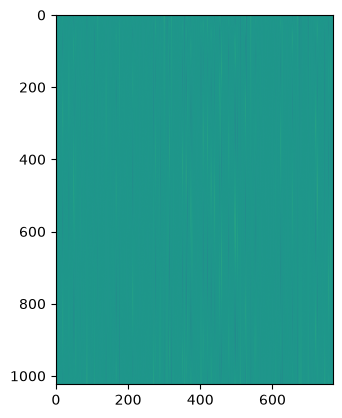

In [9]:
import matplotlib.pyplot as plt

plt.imshow(sd_hf["transformer.wpe.weight"])


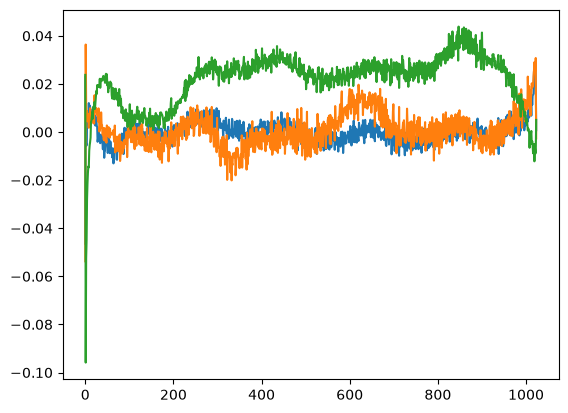

In [10]:
plt.plot(sd_hf["transformer.wpe.weight"][:, 150])
plt.plot(sd_hf["transformer.wpe.weight"][:, 200])
plt.plot(sd_hf["transformer.wpe.weight"][:, 250])

In [11]:
from transformers import pipeline, set_seed
generator = pipeline("text-generation", model="gpt2")
set_seed(42)
generator("Hello, i am a student", max_length=30,num_return_sequences=5)

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 20316.05it/s]
[transformers] Passing `generation_config` together with generation-related arguments=({'num_return_sequences', 'max_length'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=256) and `max_length`(=30) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer GPT2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_outp

[{'generated_text': 'Hello, i am a student in engineering, and I am looking for something to make my life more enjoyable. i need to make a living. my dream is to be a teacher for myself with a solid foundation in computer science and engineering. i have already worked with several other students. i am looking for a partner. i am looking for someone to help me get started. i am in college and i am looking to be able to get out of bed for one more year. I am very excited and want to help out. this will mean a lot to me. i am looking for a job to learn more about the computer science and engineering fields. i am looking for a job that will allow me to be involved in the next generation of computer science and engineering. e.g. a computer science graduate program. i am looking for a job where i can participate in some of the projects that we are working on. i am looking for a partner to help me move beyond my current job and into a new field. i am looking for a job that will allow me to wo

In [2]:
import torch
import torch.nn as nn

In [ ]:
c_attn = nn.Linear(384, 3 * 384)

In [43]:
B = 8
T = 256
C = 384
x = torch.randn(B, T, C)

In [44]:
qkv = c_attn(x) # (B, T, C) @ (C, 3 * C) --> (B, T, 3 * C)

In [46]:
q, k, v = qkv.split(384, 2)

In [47]:
k.view(B, T, 6, C // 6).shape#.transpose(1, 2) # (B, n_head, T, head_size)

torch.Size([8, 256, 6, 64])

In [48]:
k = k.view(B, T, 6, C // 6).transpose(1, 2)
q = q.view(B, T, 6, C // 6).transpose(1, 2)
v = v.view(B, T, 6, C // 6).transpose(1, 2)


In [28]:
q.shape, k.shape


(torch.Size([8, 6, 256, 64]), torch.Size([8, 6, 256, 64]))

In [31]:
(q @ k.transpose(3, 2)).shape

torch.Size([8, 6, 256, 256])

In [49]:
import math
from torch.nn import functional as F

bias = torch.tril(torch.ones((T, T))).view(1, 1, T, T)
att = (q @ k.transpose(-2, -1)) * (
    1.0 / math.sqrt(k.shape[-1])
)  # (B, n_heads, T, T)
att = att.masked_fill(bias[:, :, :T, :T] == 0, float("-inf"))
att = F.softmax(att, dim=-1)
y = att @ v  # (B, n_heads, T, T) * (B, n_heads, T, head_size) --> (B, n_heads, T, head_size)


In [56]:
y.transpose(1, 2).contiguous().view(B, T, C).shape

torch.Size([8, 256, 384])

In [57]:
y.shape

torch.Size([8, 6, 256, 64])